In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Configuración visual
plt.style.use("default")
sns.set_context("notebook")

# Para reproducibilidad
RANDOM_STATE = 42


In [2]:
df_2324 = pd.read_csv("season-2324.csv")
df_2425 = pd.read_csv("season-2425.csv")

print(df_2324.shape, df_2425.shape)
df = pd.concat([df_2324, df_2425], ignore_index=True)

print("Dataset combinado:", df.shape)


(380, 22) (380, 22)
Dataset combinado: (760, 22)


In [3]:
df.head()
df.columns


Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG',
       'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC',
       'HY', 'AY', 'HR', 'AR'],
      dtype='object')

In [4]:
df["FTR"].value_counts()
df["FTR"].value_counts(normalize=True)


,proportion
FTR,
H,0.442105
A,0.289474
D,0.268421


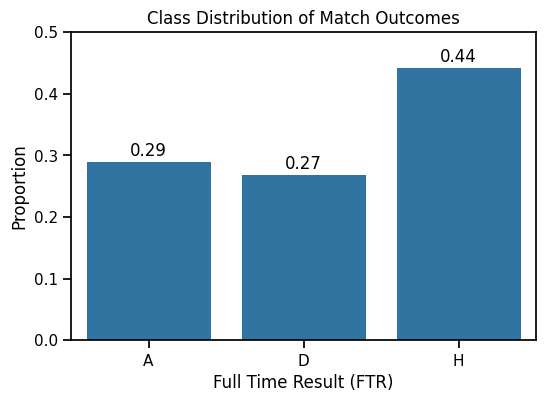

In [20]:
# Distribución de clases del target
class_dist = df["FTR"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(
    x=class_dist.index,
    y=class_dist.values
)

plt.xlabel("Full Time Result (FTR)")
plt.ylabel("Proportion")
plt.title("Class Distribution of Match Outcomes")

# Mostrar valores encima de las barras
for i, v in enumerate(class_dist.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.ylim(0, 0.5)
plt.show()


In [5]:
features = [
    "HTHG", "HTAG",
    "HS", "AS",
    "HST", "AST",
    "HF", "AF",
    "HC", "AC",
    "HY", "AY",
    "HR", "AR"
]

X = df[features].copy()
y = df["FTR"]


In [6]:
X["GoalDiff_HT"] = df["HTHG"] - df["HTAG"]
X["ShotDiff"] = df["HS"] - df["AS"]
X["ShotOnTargetDiff"] = df["HST"] - df["AST"]
X["FoulDiff"] = df["HF"] - df["AF"]
X["CornerDiff"] = df["HC"] - df["AC"]
X["CardDiff"] = (df["HY"] + df["HR"]) - (df["AY"] + df["AR"])


In [7]:
X.isnull().sum()


,0
HTHG,0
HTAG,0
HS,0
AS,0
HST,0
AST,0
HF,0
AF,0
HC,0
AC,0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

print(X_train.shape, X_test.shape)


(532, 20) (228, 20)


In [9]:
log_reg = LogisticRegression(
    max_iter=1000,
    multi_class="auto",
    random_state=RANDOM_STATE
)

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)
print("Logistic Regression - Classification Report")
print(classification_report(y_test, y_pred_lr))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression - Classification Report
              precision    recall  f1-score   support

           A       0.67      0.74      0.71        66
           D       0.44      0.23      0.30        61
           H       0.66      0.80      0.72       101

    accuracy                           0.63       228
   macro avg       0.59      0.59      0.58       228
weighted avg       0.60      0.63      0.61       228



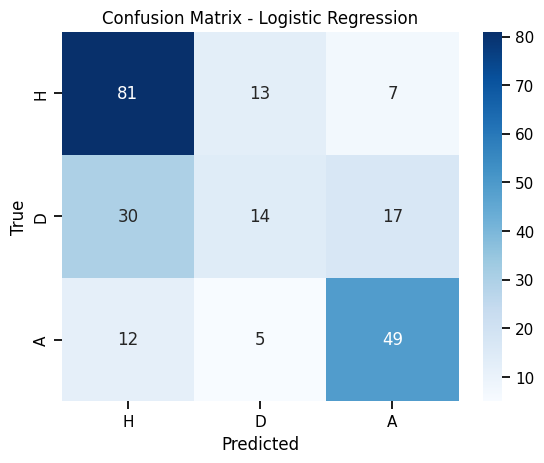

In [10]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=["H", "D", "A"])

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["H", "D", "A"],
    yticklabels=["H", "D", "A"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [11]:
from sklearn.metrics import roc_auc_score

roc_auc_lr = roc_auc_score(
    y_test,
    y_proba_lr,
    multi_class="ovr",
    average="macro"
)

print(f"Logistic Regression ROC AUC (macro): {roc_auc_lr:.4f}")



Logistic Regression ROC AUC (macro): 0.8116


Random Forest - Classification Report
              precision    recall  f1-score   support

           A       0.67      0.70      0.68        66
           D       0.38      0.26      0.31        61
           H       0.63      0.73      0.68       101

    accuracy                           0.60       228
   macro avg       0.56      0.56      0.56       228
weighted avg       0.58      0.60      0.58       228



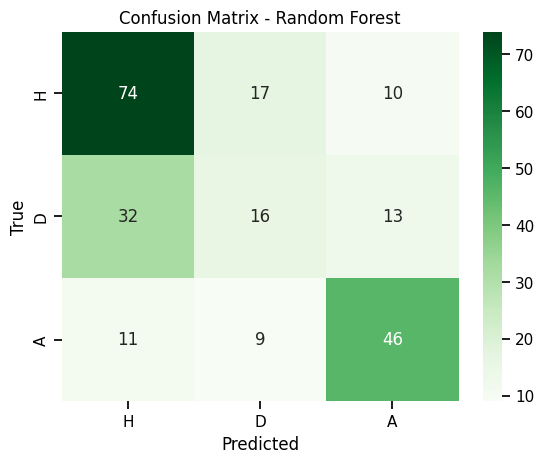

In [12]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)

print("Random Forest - Classification Report")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=["H", "D", "A"])

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["H", "D", "A"],
    yticklabels=["H", "D", "A"]
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [13]:
roc_auc_rf = roc_auc_score(
    y_test,
    y_proba_rf,
    multi_class="ovr",
    average="macro"
)

print(f"Random Forest ROC AUC (macro): {roc_auc_rf:.4f}")



Random Forest ROC AUC (macro): 0.7691


In [14]:
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)

print("Gradient Boosting - Classification Report")
print(classification_report(y_test, y_pred_gb))
roc_auc_gb = roc_auc_score(
    y_test,
    y_proba_gb,
    multi_class="ovr",
    average="macro"
)


print("Gradient Boosting ROC AUC (macro):", roc_auc_gb)


Gradient Boosting - Classification Report
              precision    recall  f1-score   support

           A       0.62      0.61      0.61        66
           D       0.37      0.33      0.35        61
           H       0.65      0.70      0.68       101

    accuracy                           0.57       228
   macro avg       0.55      0.55      0.54       228
weighted avg       0.57      0.57      0.57       228

Gradient Boosting ROC AUC (macro): 0.758445039279664


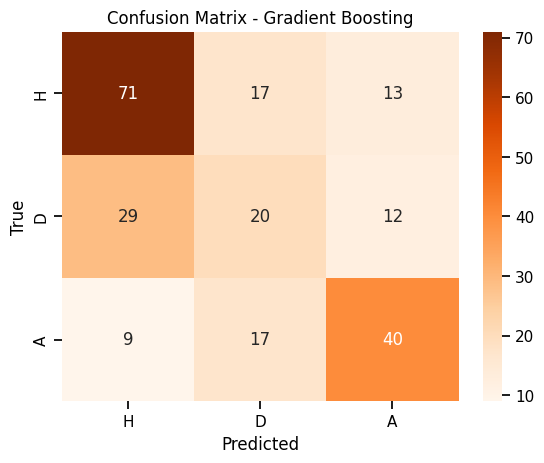

In [15]:
cm_gb = confusion_matrix(y_test, y_pred_gb, labels=["H", "D", "A"])

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["H", "D", "A"],
    yticklabels=["H", "D", "A"]
)
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [16]:
roc_auc_gb = roc_auc_score(
    y_test,
    y_proba_gb,
    multi_class="ovr",
    average="macro"
)

print(f"Gradient Boosting ROC AUC (macro): {roc_auc_gb:.4f}")


Gradient Boosting ROC AUC (macro): 0.7584


In [17]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "ROC_AUC_macro": [roc_auc_lr, roc_auc_rf, roc_auc_gb]
})

results


,Model,ROC_AUC_macro
0,Logistic Regression,0.811601
1,Random Forest,0.769149
2,Gradient Boosting,0.758445


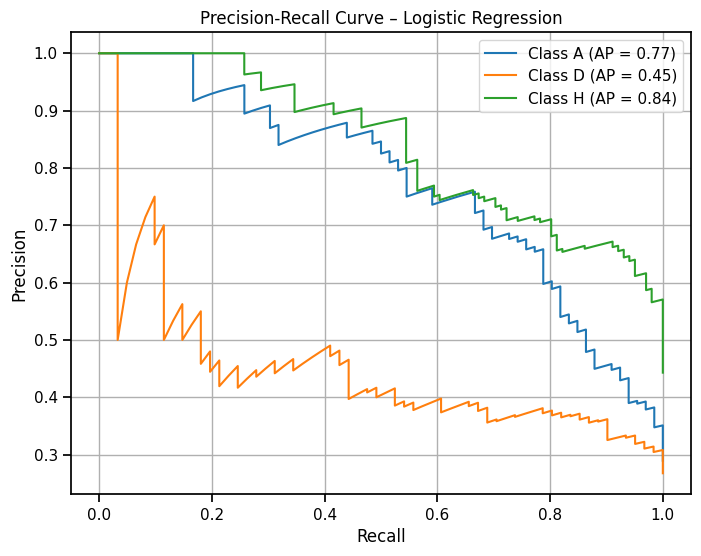

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

# Clases en el orden interno del modelo
classes = log_reg.classes_

# Binarizamos el target usando el mismo orden
y_test_bin = label_binarize(y_test, classes=classes)

# Probabilidades del modelo final
y_proba = y_proba_lr

plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_proba[:, i]
    )

    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    plt.plot(
        recall,
        precision,
        label=f"Class {cls} (AP = {ap:.2f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


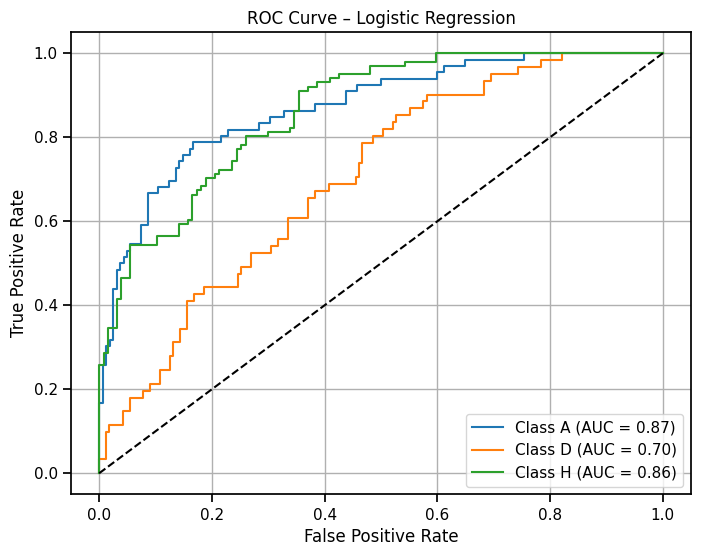

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarizamos el target (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


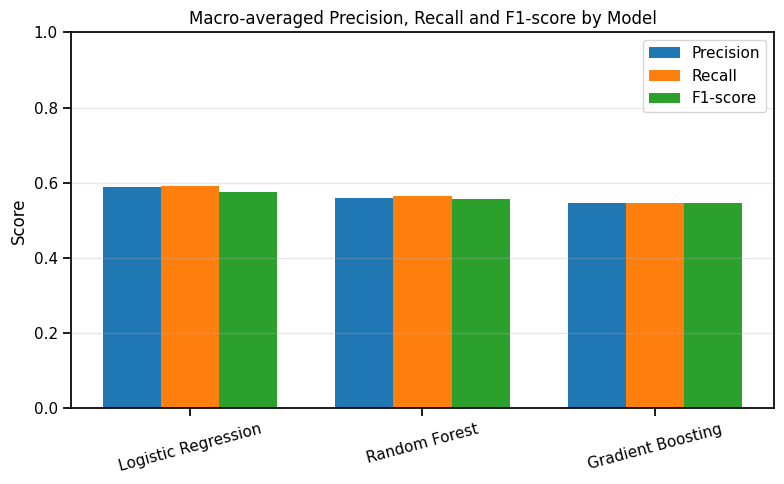

In [21]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Función para obtener métricas macro
def get_macro_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro"
    )
    return precision, recall, f1

# Métricas de cada modelo
metrics_lr = get_macro_metrics(y_test, y_pred_lr)
metrics_rf = get_macro_metrics(y_test, y_pred_rf)
metrics_gb = get_macro_metrics(y_test, y_pred_gb)

# DataFrame resumen
metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Precision": [metrics_lr[0], metrics_rf[0], metrics_gb[0]],
    "Recall":    [metrics_lr[1], metrics_rf[1], metrics_gb[1]],
    "F1-score":  [metrics_lr[2], metrics_rf[2], metrics_gb[2]]
})

# Gráfica de barras agrupadas
x = np.arange(len(metrics_df["Model"]))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, metrics_df["Precision"], width, label="Precision")
plt.bar(x,         metrics_df["Recall"],    width, label="Recall")
plt.bar(x + width, metrics_df["F1-score"],  width, label="F1-score")

plt.xticks(x, metrics_df["Model"], rotation=15)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Macro-averaged Precision, Recall and F1-score by Model")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
